## **1. Bank Account Race Condition** ##

In [1]:
import threading
import time

class BankAccount:
    """Rekening bank sederhana. use_lock menentukan apakah operasi dilindungi Lock."""
    def __init__(self, saldo_awal=1_000_000):
        self.saldo = saldo_awal
        self.lock = threading.Lock()

    def _tarik(self):
        temp = self.saldo      # 1) BACA
        time.sleep(0)          # jeda kecil -> beri kesempatan thread lain berjalan
        temp -= 1              # 2) HITUNG
        self.saldo = temp      # 3) TULIS

    def _setor(self):
        temp = self.saldo
        time.sleep(0)
        temp += 1
        self.saldo = temp

    def tarik_setor(self, n_operasi=10_000, use_lock=False):
        for _ in range(n_operasi):
            if use_lock:
                with self.lock:
                    self._tarik()
                with self.lock:
                    self._setor()
            else:
                self._tarik()
                self._setor()


def jalankan_simulasi(use_lock, n_thread=10, n_operasi=10_000, saldo_awal=1_000_000):
    rekening = BankAccount(saldo_awal)
    threads = [
        threading.Thread(target=rekening.tarik_setor, args=(n_operasi, use_lock))
        for _ in range(n_thread)
    ]

    mulai = time.perf_counter()
    for t in threads:
        t.start()
    for t in threads:
        t.join()
    selesai = time.perf_counter()

    return rekening.saldo, selesai - mulai

Saldo awal adalah **Rp1.000.000**. Kita membuat **10 thread**, dan setiap thread melakukan **10.000 kali**:

```python
saldo -= 1
saldo += 1
```

Secara logika, pasangan operasi tersebut seharusnya tidak mengubah saldo. Jadi saldo akhir yang diharapkan adalah tetap **Rp1.000.000**.

Masalahnya, operasi terhadap variabel bersama tidak otomatis menjadi satu transaksi yang tidak dapat disela. Thread dapat bergantian berjalan ketika proses membaca, menghitung, dan menulis kembali nilai `saldo`.

### *a. Percobaan Tanpa Lock* ###

In [2]:
SALDO_AWAL = 1_000_000
N_THREAD = 10
N_OPERASI = 10_000

print(f"Saldo awal        : {SALDO_AWAL:,}")
print(f"Jumlah thread     : {N_THREAD}")
print(f"Operasi per thread: {N_OPERASI:,} (tarik 1, setor 1)")
print("-" * 55)

hasil_tanpa_lock = []
for percobaan in range(10):
    saldo_akhir, durasi = jalankan_simulasi(use_lock=False, n_thread=N_THREAD, n_operasi=N_OPERASI, saldo_awal=SALDO_AWAL)
    selisih = saldo_akhir - SALDO_AWAL
    hasil_tanpa_lock.append(saldo_akhir)
    status = "BENAR" if selisih == 0 else "SALAH (race condition!)"
    print(f"Percobaan {percobaan+1}: saldo akhir = {saldo_akhir:,} (selisih {selisih:+,}) -> {status} | waktu: {durasi:.3f}s")

Saldo awal        : 1,000,000
Jumlah thread     : 10
Operasi per thread: 10,000 (tarik 1, setor 1)
-------------------------------------------------------
Percobaan 1: saldo akhir = 1,000,000 (selisih +0) -> BENAR | waktu: 0.480s
Percobaan 2: saldo akhir = 1,000,000 (selisih +0) -> BENAR | waktu: 0.521s
Percobaan 3: saldo akhir = 999,999 (selisih -1) -> SALAH (race condition!) | waktu: 0.468s
Percobaan 4: saldo akhir = 1,000,000 (selisih +0) -> BENAR | waktu: 0.460s
Percobaan 5: saldo akhir = 999,998 (selisih -2) -> SALAH (race condition!) | waktu: 0.481s
Percobaan 6: saldo akhir = 999,998 (selisih -2) -> SALAH (race condition!) | waktu: 0.519s
Percobaan 7: saldo akhir = 999,997 (selisih -3) -> SALAH (race condition!) | waktu: 0.510s
Percobaan 8: saldo akhir = 1,000,000 (selisih +0) -> BENAR | waktu: 0.499s
Percobaan 9: saldo akhir = 999,999 (selisih -1) -> SALAH (race condition!) | waktu: 0.489s
Percobaan 10: saldo akhir = 999,999 (selisih -1) -> SALAH (race condition!) | waktu: 0.458

Pada percobaan tanpa lock, race condition **tidak selalu muncul pada setiap eksekusi**. Python menggunakan GIL pada CPython, tetapi GIL bukan pengganti mekanisme sinkronisasi untuk data bersama. Karena scheduling thread tidak deterministik, hasil dapat kadang kebetulan kembali ke nilai awal.

### *b. Percobaan Dengan `threading.Lock()`* ###

In [3]:
hasil_dengan_lock = []
for percobaan in range(10):
    saldo_akhir, durasi = jalankan_simulasi(use_lock=True, n_thread=N_THREAD, n_operasi=N_OPERASI, saldo_awal=SALDO_AWAL)
    selisih = saldo_akhir - SALDO_AWAL
    hasil_dengan_lock.append(saldo_akhir)
    status = "BENAR" if selisih == 0 else "SALAH (race condition!)"
    print(f"Percobaan {percobaan+1}: saldo akhir = {saldo_akhir:,} (selisih {selisih:+,}) -> {status} | waktu: {durasi:.3f}s")

Percobaan 1: saldo akhir = 1,000,000 (selisih +0) -> BENAR | waktu: 1.860s
Percobaan 2: saldo akhir = 1,000,000 (selisih +0) -> BENAR | waktu: 1.846s
Percobaan 3: saldo akhir = 1,000,000 (selisih +0) -> BENAR | waktu: 1.795s
Percobaan 4: saldo akhir = 1,000,000 (selisih +0) -> BENAR | waktu: 1.834s
Percobaan 5: saldo akhir = 1,000,000 (selisih +0) -> BENAR | waktu: 1.748s
Percobaan 6: saldo akhir = 1,000,000 (selisih +0) -> BENAR | waktu: 1.769s
Percobaan 7: saldo akhir = 1,000,000 (selisih +0) -> BENAR | waktu: 1.825s
Percobaan 8: saldo akhir = 1,000,000 (selisih +0) -> BENAR | waktu: 1.802s
Percobaan 9: saldo akhir = 1,000,000 (selisih +0) -> BENAR | waktu: 1.824s
Percobaan 10: saldo akhir = 1,000,000 (selisih +0) -> BENAR | waktu: 1.807s


Dengan `Lock`, kita akan melindungi **seluruh pasangan operasi `saldo -= 1` dan `saldo += 1`**. Ini penting: jika lock hanya dipasang pada satu operasi secara terpisah, pasangan operasi masih dapat disela oleh thread lain.

### Pembahasan

Tanpa menggunakan `Lock`, saldo akhir hampir selalu tidak sama dengan **1.000.000** dan nilainya dapat berbeda-beda setiap kali program dijalankan. Hal ini terjadi karena adanya *race condition*, yaitu ketika beberapa thread mengakses dan mengubah variabel `saldo` secara bersamaan. Operasi seperti `saldo -= 1` dan `saldo += 1` sebenarnya terdiri dari beberapa langkah, yaitu membaca nilai saldo, mengubahnya, kemudian menuliskan kembali hasilnya. Ketika beberapa thread melakukan operasi tersebut secara bersamaan, perubahan dari satu thread dapat tertimpa oleh thread lain sehingga terjadi *lost update*. Akibatnya, saldo akhir menjadi tidak sesuai dengan nilai yang seharusnya.

Sebaliknya, ketika menggunakan `Lock`, saldo akhir akan selalu tepat **1.000.000** pada setiap percobaan. `Lock` digunakan untuk melindungi bagian program yang mengakses dan mengubah variabel bersama sehingga bagian tersebut menjadi *critical section*. Hanya satu thread yang dapat memasuki *critical section* pada satu waktu, sedangkan thread lainnya harus menunggu hingga `Lock` dilepaskan. Dengan demikian, proses `saldo -= 1` dan `saldo += 1` dapat dilakukan secara aman tanpa adanya perubahan yang tertimpa oleh thread lain.

Dari segi kecepatan, program tanpa `Lock` biasanya sedikit lebih cepat karena tidak memiliki overhead untuk proses penguncian dan pelepasan *lock*. Sementara itu, penggunaan `Lock` dapat membuat program sedikit lebih lambat karena adanya proses sinkronisasi antar-thread. Namun, penggunaan `Lock` memberikan hasil yang benar dan konsisten. Oleh karena itu, **sedikit penurunan performa lebih baik daripada menghasilkan data yang salah**. Kesimpulannya, ketika beberapa thread mengakses dan mengubah data yang sama, penggunaan `threading.Lock()` sangat penting untuk mencegah *race condition* dan menjaga konsistensi data.

## **2. Producer-Consumer dengan Banyak Consumer** ##

In [9]:
import threading
import queue
import time
import random

def producer(q, jumlah_item, jumlah_consumer, nama="Producer"):
    for i in range(jumlah_item):
        item = f"item-{i}"
        time.sleep(random.uniform(0.05, 0.2)) # Simulasi waktu produksi
        q.put(item)
        print(f"[{nama}] menghasilkan: {item}")
    
    # Kirim sinyal None ke setiap consumer agar semuanya bisa berhenti
    for _ in range(jumlah_consumer):
        q.put(None)

def consumer(q, nama="Consumer"):
    while True:
        item = q.get()
        
        # Cek jika menerima sinyal berhenti (None)
        if item is None:
            q.task_done()
            print(f"    [{nama}] menerima sinyal berhenti. Keluar...")
            break
        
        time.sleep(random.uniform(0.05, 0.15)) # Simulasi waktu pemrosesan
        print(f"    [{nama}] memproses: {item}")
        q.task_done()

# --- Program Utama ---
if __name__ == "__main__":
    q = queue.Queue()
    JUMLAH_CONSUMER = 3
    JUMLAH_ITEM = 6

    # Buat Thread Producer
    t_producer = threading.Thread(
        target=producer, 
        args=(q, JUMLAH_ITEM, JUMLAH_CONSUMER, "Producer-1")
    )

    # Buat 3 Thread Consumer
    consumers = []
    for i in range(1, JUMLAH_CONSUMER + 1):
        t = threading.Thread(
            target=consumer, 
            args=(q, f"Consumer-{i}")
        )
        consumers.append(t)

    # Jalankan semua thread
    t_producer.start()
    for c in consumers:
        c.start()
    # Tunggu semua thread selesai
    t_producer.join()
    for c in consumers:
        c.join()

    print("\nSemua item sudah diproduksi dan dikonsumsi. Program selesai.")

[Producer-1] menghasilkan: item-0
    [Consumer-1] memproses: item-0
[Producer-1] menghasilkan: item-1
[Producer-1] menghasilkan: item-2
    [Consumer-2] memproses: item-1
    [Consumer-3] memproses: item-2
[Producer-1] menghasilkan: item-3
    [Consumer-1] memproses: item-3
[Producer-1] menghasilkan: item-4
    [Consumer-2] memproses: item-4
[Producer-1] menghasilkan: item-5
    [Consumer-1] menerima sinyal berhenti. Keluar...
    [Consumer-2] menerima sinyal berhenti. Keluar...
    [Consumer-3] memproses: item-5
    [Consumer-3] menerima sinyal berhenti. Keluar...

Semua item sudah diproduksi dan dikonsumsi. Program selesai.


## **3. Eksperimen `ThreadPoolExecutor`** ##

In [15]:
import time
import random
from concurrent.futures import ThreadPoolExecutor

# Fungsi simulasi pemrosesan item (I/O-bound task)
def process_item(item_id):
    # Simulasi waktu pemrosesan antara 0.05 hingga 0.15 detik
    processing_time = random.uniform(0.05, 0.15)
    time.sleep(processing_time)
    return f"Item-{item_id} selesai diproses"

def run_benchmark(workers, total_items=50):
    items = list(range(total_items))
    start_time = time.perf_counter()
    
    # Jalankan pemrosesan menggunakan ThreadPoolExecutor dengan jumlah worker tertentu
    with ThreadPoolExecutor(max_workers=workers) as executor:
        results = list(executor.map(process_item, items))
        
    end_time = time.perf_counter()
    elapsed_time = end_time - start_time
    return elapsed_time

if __name__ == "__main__":
    TOTAL_ITEMS = 50
    WORKER_CONFIGS = [2, 4, 8, 16]
    
    print("=" * 60)
    print(f" SIMULASI PEMROSESAN {TOTAL_ITEMS} ITEM DENGAN MULTITHREADING")
    print("=" * 60)
    print(f"{'Max Workers':<15} | {'Total Waktu (Detik)':<22} | {'Kecepatan relatif':<15}")
    print("-" * 60)
    
    base_time = None
    
    for workers in WORKER_CONFIGS:
        elapsed = run_benchmark(workers, TOTAL_ITEMS)
        
        # Simpan waktu untuk max_workers=2 sebagai acuan perbandingan
        if base_time is None:
            base_time = elapsed
            speedup = "1.0x (Baseline)"
        else:
            speedup = f"{base_time / elapsed:.2f}x lebih cepat"
            
        print(f"{workers:<15} | {elapsed:<22.4f} | {speedup:<15}")
        
    print("=" * 60)

 SIMULASI PEMROSESAN 50 ITEM DENGAN MULTITHREADING
Max Workers     | Total Waktu (Detik)    | Kecepatan relatif
------------------------------------------------------------
2               | 2.4605                 | 1.0x (Baseline)
4               | 1.2958                 | 1.90x lebih cepat
8               | 0.6673                 | 3.69x lebih cepat
16              | 0.3839                 | 6.41x lebih cepat


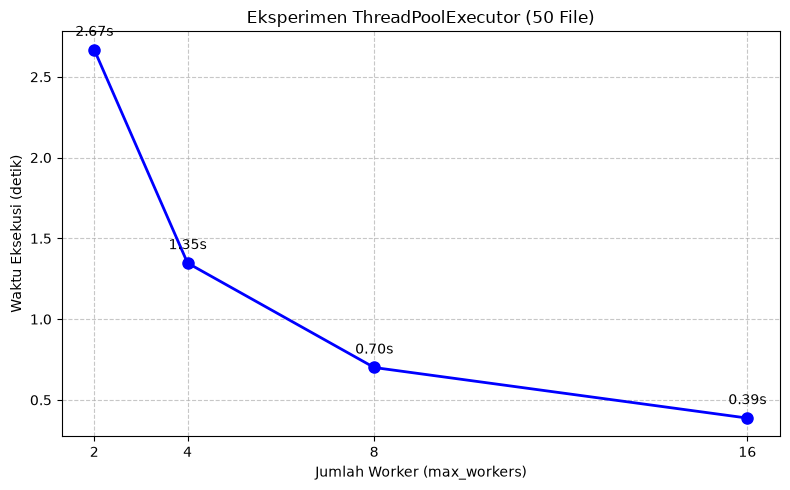

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(DAFTAR_WORKERS, hasil_waktu, marker='o', color='b', linestyle='-', linewidth=2, markersize=8)
plt.title(f"Eksperimen ThreadPoolExecutor ({JUMLAH_FILE} File)")
plt.xlabel("Jumlah Worker (max_workers)")
plt.ylabel("Waktu Eksekusi (detik)")
plt.xticks(DAFTAR_WORKERS)
plt.grid(True, linestyle='--', alpha=0.7)

for x, y in zip(DAFTAR_WORKERS, hasil_waktu):
    plt.annotate(f"{y:.2f}s", (x, y), textcoords="offset points", xytext=(0, 10), ha='center')

plt.tight_layout()
plt.show()

### Pembahasan

Menambah nilai `max_workers` secara terus-menerus tidak selalu membuat proses menjadi semakin cepat. Berdasarkan grafik, terlihat adanya pola *diminishing returns*, yaitu peningkatan kecepatan yang semakin kecil ketika jumlah worker terus ditambah. Pada awalnya, peningkatan `max_workers` dari 2 menjadi 4 dan kemudian 8 dapat memberikan percepatan yang cukup signifikan karena semakin banyak pekerjaan yang dapat dikerjakan secara paralel. Namun, setelah mencapai jumlah worker tertentu, proses akan mengalami titik jenuh (*saturation point*) sehingga penambahan worker tidak lagi memberikan peningkatan kecepatan yang berarti.

Salah satu penyebabnya adalah jumlah pekerjaan yang terbatas. Dalam kasus ini terdapat 50 file yang harus diproses. Ketika jumlah worker sudah mendekati jumlah pekerjaan yang tersedia, hampir semua file sudah dapat diproses secara bersamaan sehingga menambah worker lebih banyak tidak memberikan manfaat yang signifikan. Selain itu, setiap thread membutuhkan sumber daya dan proses penjadwalan dari sistem operasi. Semakin banyak thread yang digunakan, semakin besar pula *overhead* seperti penggunaan memori dan *context switching*. Akibatnya, keuntungan dari paralelisme dapat berkurang karena sebagian waktu digunakan untuk mengelola thread.

Dengan demikian, **menambah `max_workers` hanya akan mempercepat proses sampai batas tertentu**. Setelah mencapai kapasitas paralelisme yang efektif, penambahan worker akan memberikan peningkatan performa yang semakin kecil dan bahkan dapat membuat proses menjadi lebih lambat karena adanya *overhead* pengelolaan thread. 

## **4.  Refleksi Singkat** ##

**Contoh kasus threading Python membantu :**
Threading cocok untuk program yang banyak melakukan operasi I/O,, misalnya aplikasi *web scraper* yang harus mengunduh ratusan halaman web sekaligus. Sebagian besar waktu program dihabiskan menunggu respons jaringan (I/O-bound), bukan menghitung. Saat satu thread menunggu response HTTP, GIL dilepas dan thread lain bisa berjalan, sehingga `ThreadPoolExecutor` bisa mempercepat proses unduh secara signifikan tanpa kompleksitas `multiprocessing`.

**Contoh kasus threading Python tidak banyak membantu :**
Program yang menghitung ribuan transformasi gambar resolusi tinggi (misalnya resize, filter, convolusi) secara murni di Python. Ini adalah pekerjaan **CPU-bound**: GIL membuat hanya satu thread yang benar-benar mengeksekusi bytecode Python pada satu waktu, sehingga menambah thread tidak mempercepat komputasi bisa jadi malah melambat karena overhead context switching. Untuk kasus ini, `multiprocessing` (yang menjalankan proses terpisah dengan interpreter dan memori masing-masing, sehingga tidak terkena batasan GIL) adalah pilihan yang jauh lebih tepat untuk memanfaatkan banyak core CPU secara nyata.